  0%|          | 0/3 [00:00<?, ?it/s]

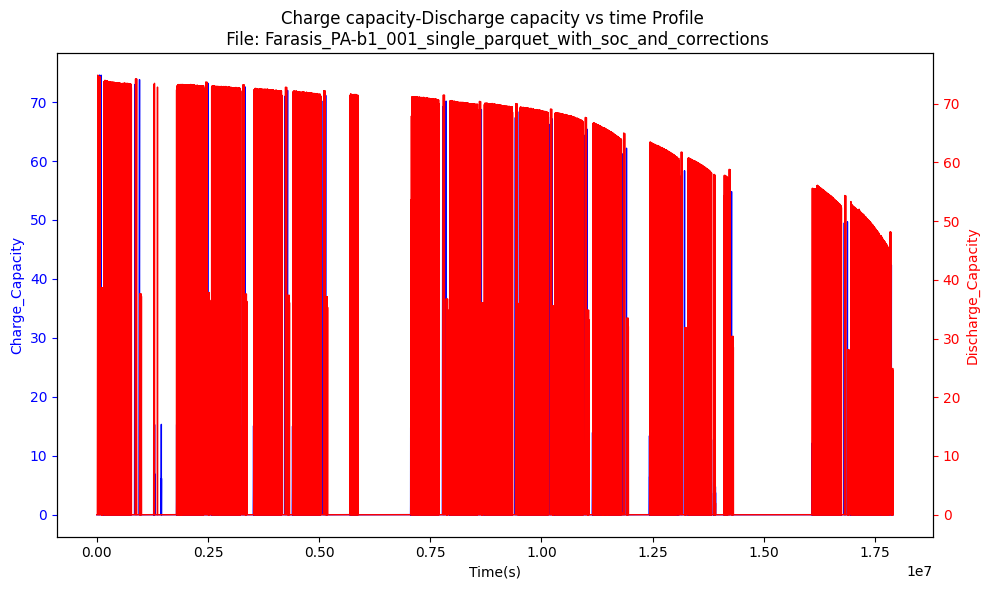

 33%|███▎      | 1/3 [01:54<03:49, 114.77s/it]

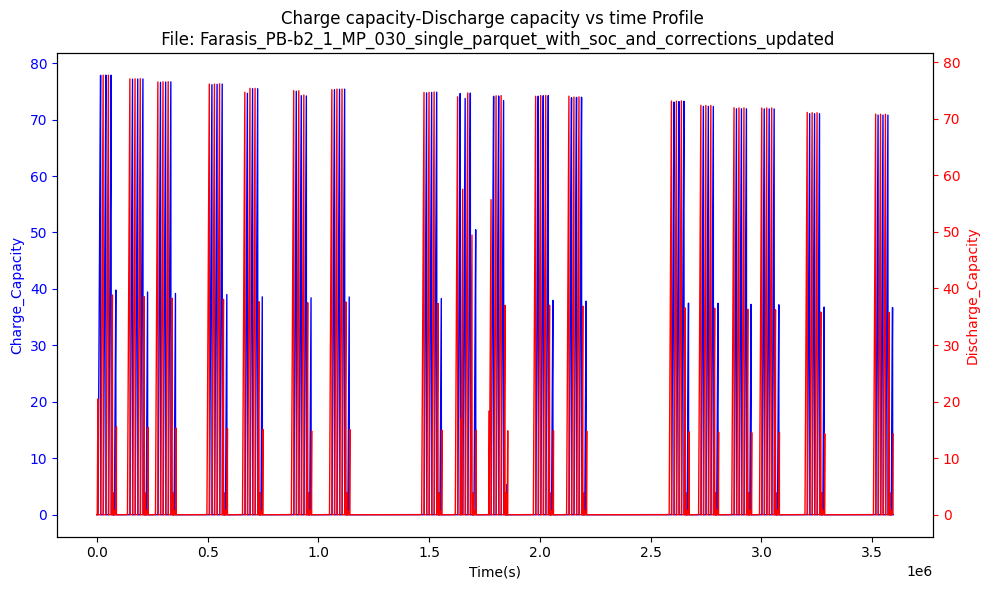

 67%|██████▋   | 2/3 [02:49<01:19, 79.31s/it] 

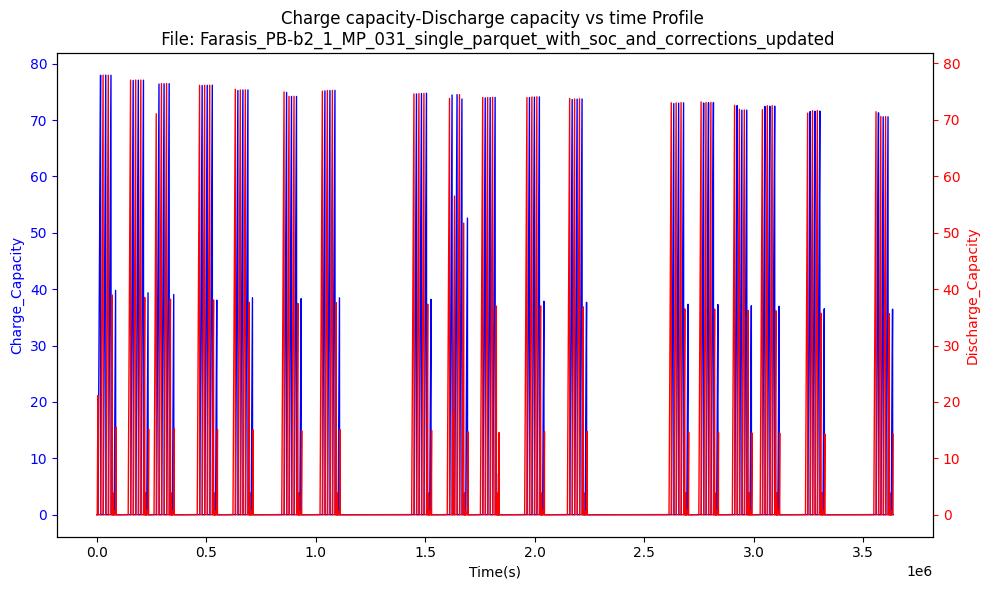

100%|██████████| 3/3 [03:14<00:00, 64.79s/it]


In [1]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


def _get_field(obj, key, default=None):
    if isinstance(obj, dict):
        return obj.get(key, default)
    return getattr(obj, key, default)


path = 'E:/第三人生/HKUSTgz/BatteryLife/dataset/processed/Farasis/'
ppath = Path(path)
if not ppath.exists():
    raise FileNotFoundError(f'Path not found: {ppath}')

files = sorted([i for i in os.listdir(path) if i.endswith('.pkl')])
if len(files) == 0:
    raise FileNotFoundError(f'No pkl files found under: {ppath}')

for file in tqdm(files):
    with open(ppath / file, 'rb') as f:
        cell_data = pickle.load(f)

    filename = file.split('.pkl')[0]
    cycle_data_all = _get_field(cell_data, 'cycle_data', [])
    if len(cycle_data_all) == 0:
        print(f'SKIP {filename}: empty cycle_data')
        continue

    charge_caps = []
    discharge_caps = []
    times = []

    for cycle_data in cycle_data_all:
        current = np.asarray(_get_field(cycle_data, 'current_in_A', []), dtype=float)
        charge_capacity = np.asarray(_get_field(cycle_data, 'charge_capacity_in_Ah', []), dtype=float)
        discharge_capacity = np.asarray(_get_field(cycle_data, 'discharge_capacity_in_Ah', []), dtype=float)
        test_time = np.asarray(_get_field(cycle_data, 'time_in_s', []), dtype=float)

        min_len = min(len(current), len(charge_capacity), len(discharge_capacity), len(test_time))
        if min_len == 0:
            continue

        charge_caps.extend(charge_capacity[:min_len].tolist())
        discharge_caps.extend(discharge_capacity[:min_len].tolist())
        times.extend(test_time[:min_len].tolist())

    if len(times) == 0:
        print(f'SKIP {filename}: no valid points')
        continue

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(times, charge_caps, 'b-', linewidth=1.0)
    ax1.set_xlabel('Time(s)')
    ax1.set_ylabel('Charge_Capacity', color='b')
    ax1.tick_params(axis='y', colors='b')

    ax2 = ax1.twinx()
    ax2.plot(times, discharge_caps, 'r-', linewidth=1.0)
    ax2.set_ylabel('Discharge_Capacity', color='r')
    ax2.tick_params(axis='y', colors='r')

    plt.title('Charge capacity-Discharge capacity vs time Profile \n File: {}'.format(filename))
    plt.tight_layout()
    plt.show()